# Slideseq MGGP SVGP Exploratory

Explore posterior means and variances of the MGGP-SVGP NSF model trained on SlideseqV2. Update the checkpoint path and rerun to refresh the plots.

In [32]:
# Imports & configuration
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch
from scipy.special import softplus

from gpzoo.models import build_model
from gpzoo.datasets.slideseq.common import load_slideseq_with_groups

SVG_MODEL_PATH = Path('/gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/slideseq/slideseq_mggp_svgp.pth').resolve()
LENGTHSCALE = 20.0
GROUP_DIFF = 10.0
DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')
print(f'Checkpoint: {SVG_MODEL_PATH}')


Using device: cpu
Checkpoint: /gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/slideseq/slideseq_mggp_svgp.pth


In [2]:
# Load tensors and rebuild the MGGP-SVGP model
X, Y, GROUPS_X, N_GROUPS, V_INIT = load_slideseq_with_groups()
print(f'Spatial points: {X.shape[0]} | Genes: {Y.shape[0]} | Groups: {N_GROUPS}')

if not SVG_MODEL_PATH.is_file():
    raise FileNotFoundError(f'Checkpoint not found at {SVG_MODEL_PATH}')

model, _ = build_model(
    'slideseq/svgp_mggp_nsf',
    checkpoint_path=str(SVG_MODEL_PATH),
    X=X,
    groupsX=GROUPS_X,
    Y=Y,
    V=V_INIT,
    L=12,
    lengthscale=LENGTHSCALE,
    kernel_kwargs={
        'sigma': 1.0,
        'group_diff_param': GROUP_DIFF,
    },
    jitter=1e-5,
    num_inducing=min(4000, X.shape[0]),
    device=DEVICE,
    seed=123,
)
model.eval();


Spatial points: 41783 | Genes: 17702 | Groups: 14
Loaded checkpoint from /gladstone/engelhardt/home/lchumpitaz/gitclones/GPzoo/models/slideseq/slideseq_mggp_svgp.pth


In [30]:
def plot_factors(factors, coords, title=None, size=3, s=4.0, vmin=None, vmax=None, cmap='turbo'):
    factors = np.asarray(factors)
    L = factors.shape[0]
    cols = min(4, L)
    rows = (L + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size), squeeze=False)
    for idx, ax in np.ndenumerate(axes):
        ax_idx = idx[0] * cols + idx[1]
        if ax_idx >= L:
            ax.axis('off')
            continue
        ax.scatter(coords[:, 0], coords[:, 1], c=factors[ax_idx], s=s, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    # return fig


In [3]:
# Posterior means and variances for the latent factors
with torch.no_grad():
    qF, _, _ = model.prior(X=X.to(DEVICE), groupsX=GROUPS_X.to(DEVICE))

factor_means = qF.mean.detach().cpu().numpy()
factor_vars = (qF.scale.detach().cpu().numpy()) ** 2
coords = X.cpu().numpy()
print(f'Posterior factor matrix: {factor_means.shape}')


Posterior factor matrix: (12, 41783)


In [4]:
factor_means

array([[-5.061493 , -6.047068 , -5.048002 , ..., -4.3313   , -4.935802 ,
        -6.9360332],
       [-5.2153034, -5.9280953, -5.218773 , ..., -6.024755 , -5.646559 ,
        -6.3382163],
       [-5.244138 , -5.7080064, -5.2427716, ..., -6.3421564, -5.9753532,
        -6.100854 ],
       ...,
       [-5.5307493, -3.6736887, -5.522923 , ..., -6.3004236, -5.733209 ,
        -4.4698625],
       [-5.0069942, -5.392833 , -5.006167 , ..., -5.98573  , -5.6114025,
        -5.7981825],
       [-4.9458394, -5.2773695, -4.939389 , ..., -5.9663057, -5.7606754,
        -4.769815 ]], shape=(12, 41783), dtype=float32)

In [23]:
# Plotting helpers
plt.rcParams['figure.figsize'] = (6, 5)

def plot_factor(values, title, cmap='viridis', vmin=None, vmax=None):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    plt.figure(figsize=(6, 5))
    plt.scatter(coords[:, 0], -coords[:, 1], c=values, s=0.2, cmap=cmap, norm=norm)
    plt.colorbar(label=title)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    # plt.
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


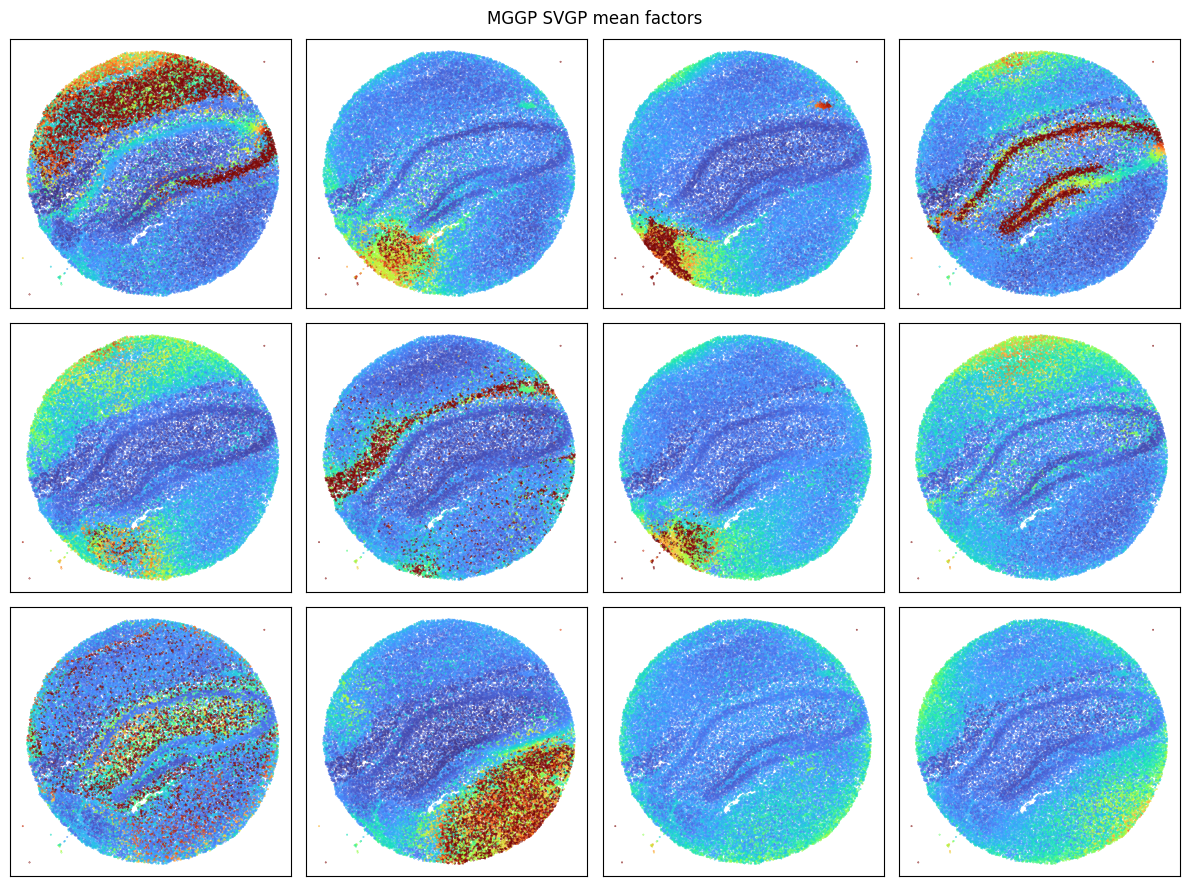

In [35]:
# Mean factors
vmax = np.percentile(softplus(factor_means), 95)
plot_factors(softplus(factor_means), coords, title='MGGP SVGP mean factors', vmin=0, vmax=vmax, s=0.1)


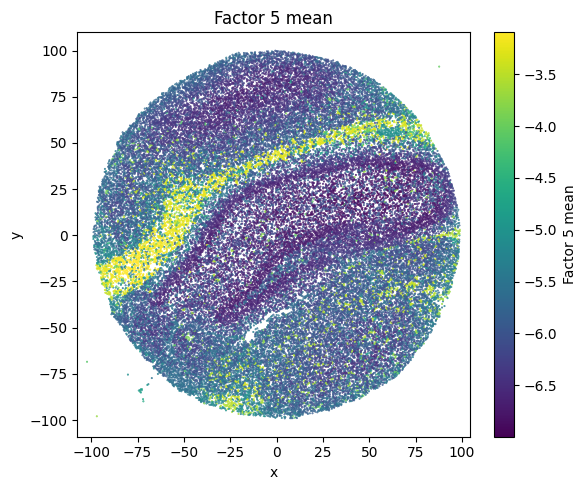

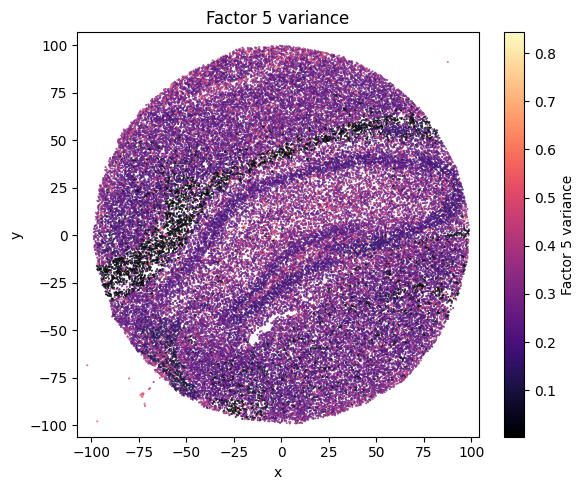

In [29]:
# Toggle the factor index to inspect different components
FACTOR_INDEX = 5

if not 0 <= FACTOR_INDEX < factor_means.shape[0]:
    raise ValueError('FACTOR_INDEX out of range')

plot_factor(factor_means[FACTOR_INDEX], f'Factor {FACTOR_INDEX} mean')
plot_factor(factor_vars[FACTOR_INDEX], f'Factor {FACTOR_INDEX} variance', cmap='magma')


In [7]:
model.prior.kernel.lengthscale

Parameter containing:
tensor(20.7148, requires_grad=True)